In [7]:
import os
import mne
import numpy as np
# from sentry_sdk.utils import epoch
from sklearn.preprocessing import StandardScaler
import scipy.io as sio
from torch import optim
from typing import List
from torch.utils.data import DataLoader,TensorDataset
from sklearn.metrics import classification_report,confusion_matrix
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
def calculate_accuracy(loader:DataLoader,model:nn.Module,device:str)->float:
    correct = 0
    total = 0
    with torch.no_grad():
        for datas,labels in loader:
            datas,labels = datas.to(device),labels.to(device)
            outputs = model(datas)
            _,predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def get_losses(losses:List[float],loader:DataLoader,model:nn.Module,device:str)->List[float]:
    loss = 0
    with torch.no_grad():
        for i,(inputs,targets)in enumerate(loader):
            inputs,targets = inputs.to(device),targets.to(device)
            outputs = model(inputs)
            l = criterion(outputs,targets)
            loss += l.item()
        loss /= len(loader)
        losses.append(loss)
    return losses
def get_predictions(loader:DataLoader,model:nn.Module,device:str):
    all_targets = []
    all_predictions = []
    with torch.no_grad():
        for i ,(inputs,targets) in enumerate(loader):
            inputs,targets = inputs.to(device),targets.to(device)
            outputs = model(inputs)
            _,predicted = torch.max(outputs,1)
            all_targets.extend(targets.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
    return all_targets,all_predictions

def loss_curve( epoches : int , train_losses : List[float],val_losses :List[float],model:str = '',folder_path = '',sub = '')->None:
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
    plt.figure(figsize = (10,5))
    plt.plot(range(1,epoches +1),train_losses,label = 'Train Loss')
    plt.plot(range(1,epoches +1),val_losses,label = 'Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('loss')
    plt.title(f'Sub{sub+1} Training and Testing Loss Curve')
    plt.legend()
    img_path = os.path.join(folder_path,'loss_curve.png')
    plt.savefig(img_path)
    plt.show(block = False)
    plt.close()

def plot_confusion_matrix(
        all_train_targets:np.ndarray,
        all_train_predictions:np.ndarray,
        all_test_targets:np.ndarray,
        all_test_predictions:np.ndarray,
        model:str = '',
        folder_path ='',
        sub = ''
)->None:
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    plt.figure(figsize = (8,6))
    cm = confusion_matrix(all_train_targets,all_train_predictions)
    sns.heatmap(cm,annot = True,fmt = 'd',cmap = 'Blues',xticklabels = range(2),yticklabels = range(2))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Sub{sub+1} Confusion Matrix-Train')
    plt.savefig(os.path.join(folder_path,f'Sub{sub+1} Confusion Matrix-Train'))
    plt.show(block = False)
    plt.close()

    plt.figure(figsize = (8,6))
    cm = confusion_matrix(all_test_targets,all_test_predictions)
    sns.heatmap(cm,annot = True,fmt = 'd',cmap = 'Blues',xticklabels =range(2),yticklabels = range(2))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Sub{sub+1} Confusion Matrix-Test')
    plt.savefig(os.path.join(folder_path,f'Sub{sub+1} Confusion Matrix-Test'))
    plt.show(block = False)
    plt.close()

def print_Confusion_matrix(
        all_train_targets:np.ndarray,
        all_train_predictions:np.ndarray,
        all_test_targets:np.ndarray,
        all_test_predictions:np.ndarray,
        model:str = '',
        folder_path ='',
        sub = ''
):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    report_train = classification_report(all_train_targets,all_train_predictions)
    report_test  = classification_report(all_test_targets, all_test_predictions)

    with open(os.path.join(folder_path,f'Sub{sub+1}Report.txt'),'w')as f:
        f.write('\nReport Train')
        f.write(report_train)
        f.write('\nReport Test')
        f.write(report_test)

In [9]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    """保持与之前一致的 EEGNet-style 前端"""
    def __init__(self, channels=17, samples=384, F1=16, D=2, F2=32,
                 kernelLength=32, kernelLength2=16, drop_out=0.5):
        super().__init__()
        self.F1 = F1
        self.D = D
        self.F2 = F2

        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, kernelLength), stride=1,
                      padding=(0, kernelLength // 2), bias=False),
            nn.BatchNorm2d(F1)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(F1, F1 * D, kernel_size=(channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(p=drop_out)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(F1 * D, F2, kernel_size=(1, kernelLength2), stride=1,
                      padding=(0, kernelLength2 // 2), groups=F1 * D, bias=False),
            nn.Conv2d(F2, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 16)),
            nn.Dropout(p=drop_out)
        )

    def forward(self, x):
        if len(x.shape) != 4:
            x = x.unsqueeze(1)  # (B, 1, C, T)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)      # (B, F2, 1, T_reduced)
        return x


class TransformerEncoderLayer(nn.Module):
    """保持不变"""
    def __init__(self, dim, heads=8, mlp_dim=512, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        residual = x
        x = self.norm1(x)
        attn_out, _ = self.attn(x, x, x)
        x = residual + attn_out

        residual = x
        x = self.norm2(x)
        x = residual + self.mlp(x)
        return x


class EEGViT(nn.Module):
    def __init__(self, n_classes=2, channels=17, samples=384,
                 drop_out=0.5, kernelLength=32, kernelLength2=16,
                 F1=16, D=2, F2=32,
                 vit_dim=256, vit_depth=6, vit_heads=8,
                 vit_mlp_dim=512, vit_dropout=0.1):
        super(EEGViT, self).__init__()

        self.patch_embed = PatchEmbedding(channels, samples, F1, D, F2,
                                          kernelLength, kernelLength2, drop_out)

        # 计算卷积后时间维度（精确计算）
        t_reduced = ((samples // 8) // 16)   # 384 → 3
        self.num_patches = t_reduced         # 每个时间步作为一个 patch
        self.patch_dim = F2                  # 每个 patch 的特征维度

        # 线性投影：将每个 patch 的 F2 维特征投影到 vit_dim
        self.proj = nn.Linear(self.patch_dim, vit_dim)

        # 可学习的位置编码和 CLS token
        self.cls_token = nn.Parameter(torch.randn(1, 1, vit_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, vit_dim))

        # Transformer 编码器
        self.transformer = nn.ModuleList([
            TransformerEncoderLayer(vit_dim, vit_heads, vit_mlp_dim, vit_dropout)
            for _ in range(vit_depth)
        ])

        self.norm = nn.LayerNorm(vit_dim)

        # 分类头（与原 EEGNet 保持一致，使用 Softmax）
        self.classifier = nn.Sequential(
            nn.Linear(vit_dim, n_classes),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        # CNN 前端特征提取
        x = self.patch_embed(x)                     # (B, F2, 1, T_reduced)

        # 转为 patch 序列：(B, num_patches, patch_dim)
        B = x.shape[0]
        x = x.squeeze(2)                            # (B, F2, T_reduced)
        x = x.permute(0, 2, 1)                      # (B, T_reduced, F2)
        x = self.proj(x)                            # (B, T_reduced, vit_dim)

        # 添加 CLS token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)       # (B, 1 + num_patches, vit_dim)

        # 添加位置编码
        x = x + self.pos_embed

        # Transformer 编码
        for layer in self.transformer:
            x = layer(x)

        x = self.norm(x)
        cls_output = x[:, 0]                        # 取 CLS token 输出

        # 分类
        out = self.classifier(cls_output)
        return out

In [10]:
import h5py
import numpy as np

# 读取文件
with h5py.File('seed.mat', 'r') as f:
    # 查看文件里有哪些键（可选）
    print("文件中的变量：", list(f.keys()))

    # 提取数据（注意 v7.3 文件里数组通常需要转置或额外处理）
    EEGsample = np.array(f['EEGsample'])
    subindex   = np.array(f['subindex'])
    substate   = np.array(f['substate'])
    EEGsample = EEGsample.transpose(2,1,0)
print("EEGsample shape:", EEGsample.shape)
print("subindex shape:", subindex.shape)
print("substate shape:", substate.shape)


文件中的变量： ['EEGsample', 'subindex', 'substate']
EEGsample shape: (11396, 17, 384)
subindex shape: (1, 11396)
substate shape: (1, 11396)


In [11]:
save_path = os.path.join(os.getcwd(), 'results')
if not os.path.exists(save_path):
    os.makedirs(save_path)

path = os.path.join(save_path, 'EEGNet')
if not os.path.exists(path):
    os.makedirs(path)
report_path = os.path.join(path, 'report.txt')

torch.manual_seed(2024)

=== 数据维度检查 ===
inpt.shape  = torch.Size([11396, 1, 17, 384])
label.shape = torch.Size([11396])
index.shape = torch.Size([11396])

========== 开始 10 折交叉验证 ==========

========== 第 1/10 折 ==========
Fold [1/10], Epoch [1/500], Step [1/41], Loss: 0.6443
Fold [1/10], Epoch [1/500], Step [11/41], Loss: 0.6622
Fold [1/10], Epoch [1/500], Step [21/41], Loss: 0.6519
Fold [1/10], Epoch [1/500], Step [31/41], Loss: 0.6619
Fold [1/10], Epoch [1/500], Step [41/41], Loss: 0.6700
Fold [1/10], Epoch [101/500], Step [1/41], Loss: 0.4897
Fold [1/10], Epoch [101/500], Step [11/41], Loss: 0.4684
Fold [1/10], Epoch [101/500], Step [21/41], Loss: 0.4770
Fold [1/10], Epoch [101/500], Step [31/41], Loss: 0.4754
Fold [1/10], Epoch [101/500], Step [41/41], Loss: 0.6341
Fold [1/10], Epoch [201/500], Step [1/41], Loss: 0.4488
Fold [1/10], Epoch [201/500], Step [11/41], Loss: 0.4482
Fold [1/10], Epoch [201/500], Step [21/41], Loss: 0.4650
Fold [1/10], Epoch [201/500], Step [31/41], Loss: 0.4686
Fold [1/10], Epoch 

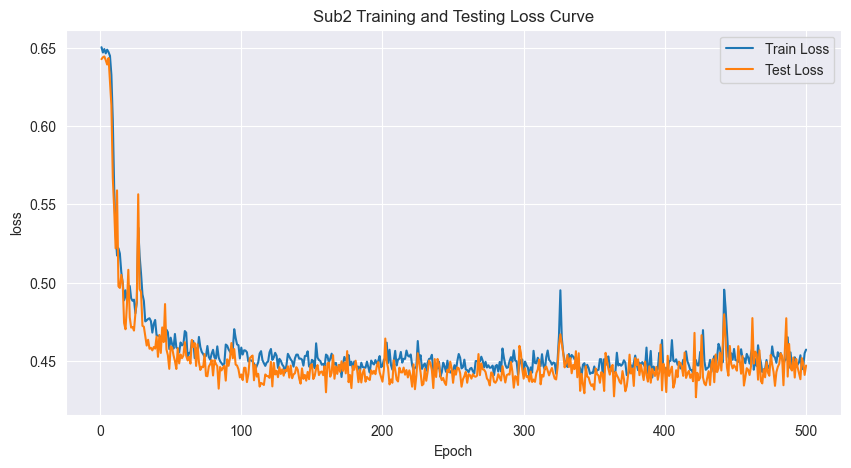

<Figure size 640x480 with 0 Axes>

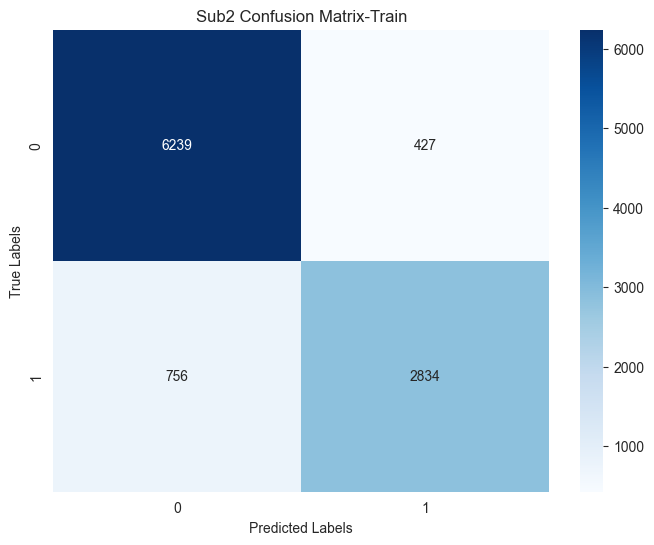

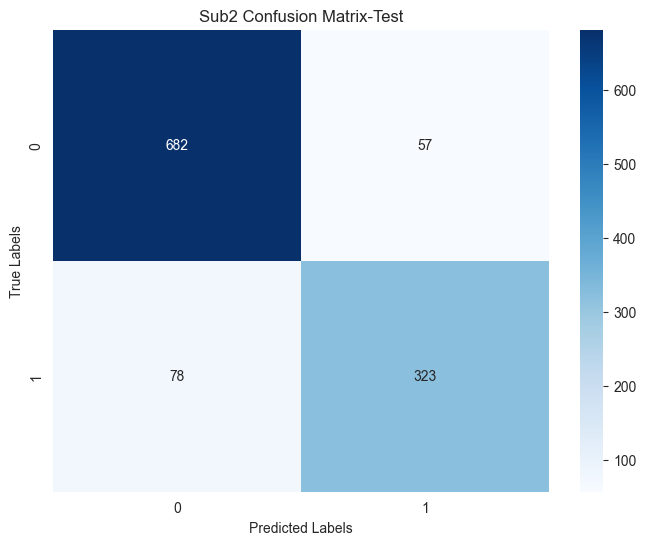

第 1 折 测试准确率: 88.16%

========== 第 2/10 折 ==========
Fold [2/10], Epoch [1/500], Step [1/41], Loss: 0.7316
Fold [2/10], Epoch [1/500], Step [11/41], Loss: 0.6855
Fold [2/10], Epoch [1/500], Step [21/41], Loss: 0.6404
Fold [2/10], Epoch [1/500], Step [31/41], Loss: 0.6964
Fold [2/10], Epoch [1/500], Step [41/41], Loss: 0.6738
Fold [2/10], Epoch [101/500], Step [1/41], Loss: 0.4088
Fold [2/10], Epoch [101/500], Step [11/41], Loss: 0.4525
Fold [2/10], Epoch [101/500], Step [21/41], Loss: 0.4495
Fold [2/10], Epoch [101/500], Step [31/41], Loss: 0.4496
Fold [2/10], Epoch [101/500], Step [41/41], Loss: 0.4219
Fold [2/10], Epoch [201/500], Step [1/41], Loss: 0.5151
Fold [2/10], Epoch [201/500], Step [11/41], Loss: 0.5535
Fold [2/10], Epoch [201/500], Step [21/41], Loss: 0.5026
Fold [2/10], Epoch [201/500], Step [31/41], Loss: 0.5056
Fold [2/10], Epoch [201/500], Step [41/41], Loss: 0.4983
Fold [2/10], Epoch [301/500], Step [1/41], Loss: 0.4396
Fold [2/10], Epoch [301/500], Step [11/41], Loss: 

<Figure size 640x480 with 0 Axes>

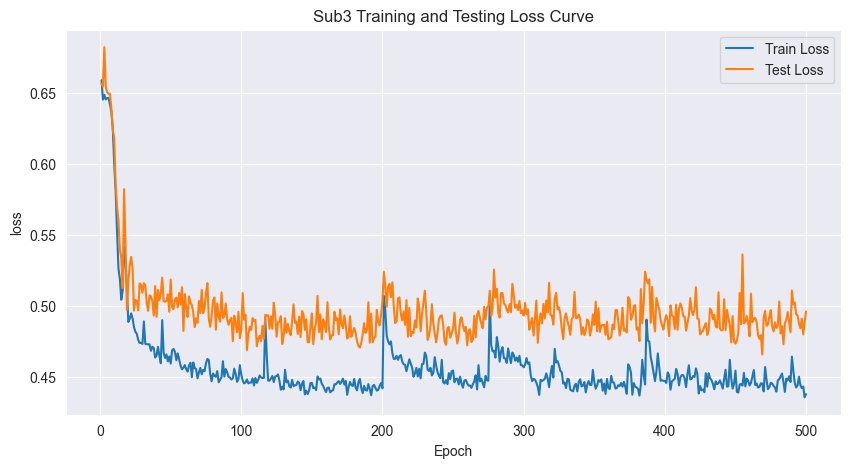

<Figure size 640x480 with 0 Axes>

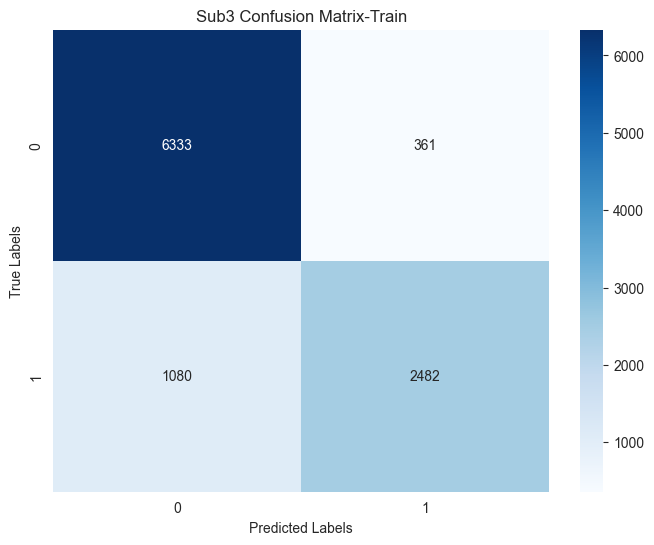

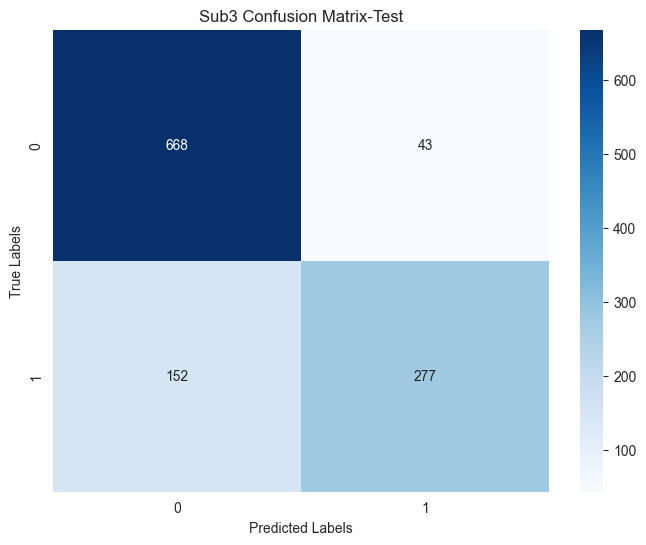

第 2 折 测试准确率: 82.89%

========== 第 3/10 折 ==========
Fold [3/10], Epoch [1/500], Step [1/41], Loss: 0.6669
Fold [3/10], Epoch [1/500], Step [11/41], Loss: 0.6291
Fold [3/10], Epoch [1/500], Step [21/41], Loss: 0.6497
Fold [3/10], Epoch [1/500], Step [31/41], Loss: 0.6638
Fold [3/10], Epoch [1/500], Step [41/41], Loss: 0.6273
Fold [3/10], Epoch [101/500], Step [1/41], Loss: 0.4600
Fold [3/10], Epoch [101/500], Step [11/41], Loss: 0.4416
Fold [3/10], Epoch [101/500], Step [21/41], Loss: 0.4554
Fold [3/10], Epoch [101/500], Step [31/41], Loss: 0.4106
Fold [3/10], Epoch [101/500], Step [41/41], Loss: 0.3592
Fold [3/10], Epoch [201/500], Step [1/41], Loss: 0.4351
Fold [3/10], Epoch [201/500], Step [11/41], Loss: 0.4248
Fold [3/10], Epoch [201/500], Step [21/41], Loss: 0.4277
Fold [3/10], Epoch [201/500], Step [31/41], Loss: 0.4519
Fold [3/10], Epoch [201/500], Step [41/41], Loss: 0.5012
Fold [3/10], Epoch [301/500], Step [1/41], Loss: 0.4328
Fold [3/10], Epoch [301/500], Step [11/41], Loss: 

<Figure size 640x480 with 0 Axes>

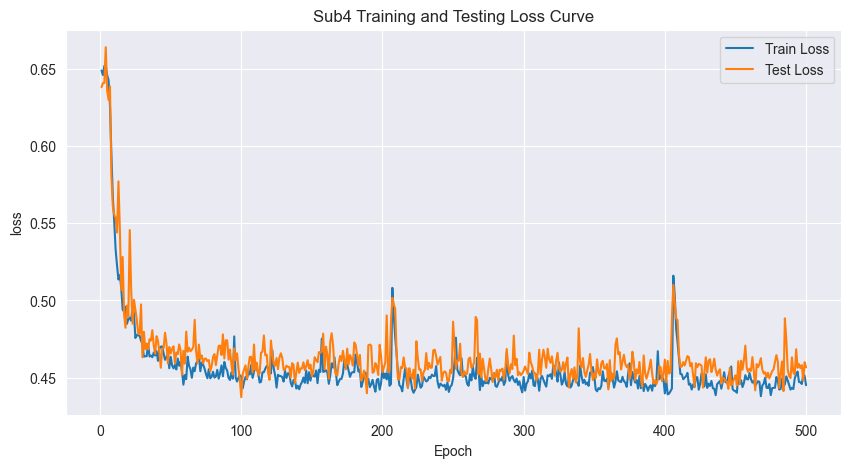

<Figure size 640x480 with 0 Axes>

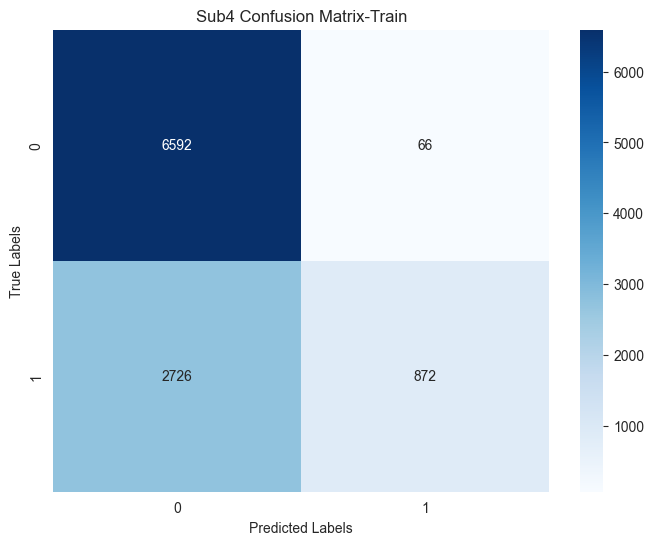

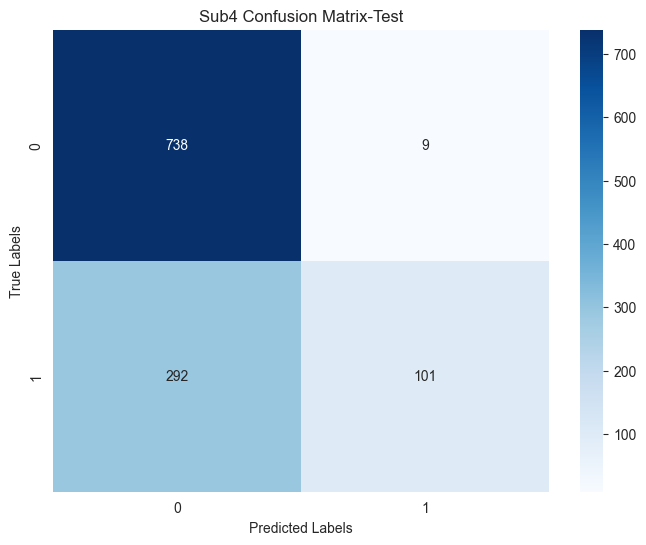

第 3 折 测试准确率: 73.60%

========== 第 4/10 折 ==========
Fold [4/10], Epoch [1/500], Step [1/41], Loss: 0.7077
Fold [4/10], Epoch [1/500], Step [11/41], Loss: 0.6129
Fold [4/10], Epoch [1/500], Step [21/41], Loss: 0.6480
Fold [4/10], Epoch [1/500], Step [31/41], Loss: 0.6551
Fold [4/10], Epoch [1/500], Step [41/41], Loss: 0.6283
Fold [4/10], Epoch [101/500], Step [1/41], Loss: 0.4757
Fold [4/10], Epoch [101/500], Step [11/41], Loss: 0.4497
Fold [4/10], Epoch [101/500], Step [21/41], Loss: 0.4143
Fold [4/10], Epoch [101/500], Step [31/41], Loss: 0.4369
Fold [4/10], Epoch [101/500], Step [41/41], Loss: 0.4466
Fold [4/10], Epoch [201/500], Step [1/41], Loss: 0.4413
Fold [4/10], Epoch [201/500], Step [11/41], Loss: 0.5237
Fold [4/10], Epoch [201/500], Step [21/41], Loss: 0.4492
Fold [4/10], Epoch [201/500], Step [31/41], Loss: 0.4405
Fold [4/10], Epoch [201/500], Step [41/41], Loss: 0.4197
Fold [4/10], Epoch [301/500], Step [1/41], Loss: 0.4731
Fold [4/10], Epoch [301/500], Step [11/41], Loss: 

<Figure size 640x480 with 0 Axes>

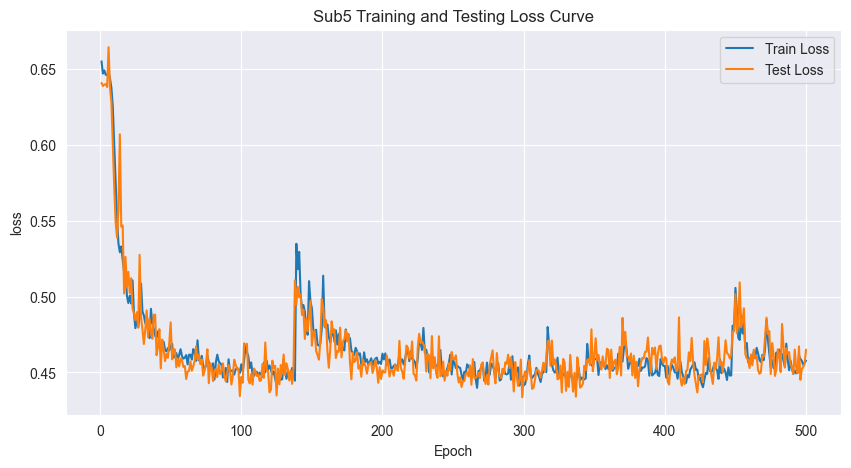

<Figure size 640x480 with 0 Axes>

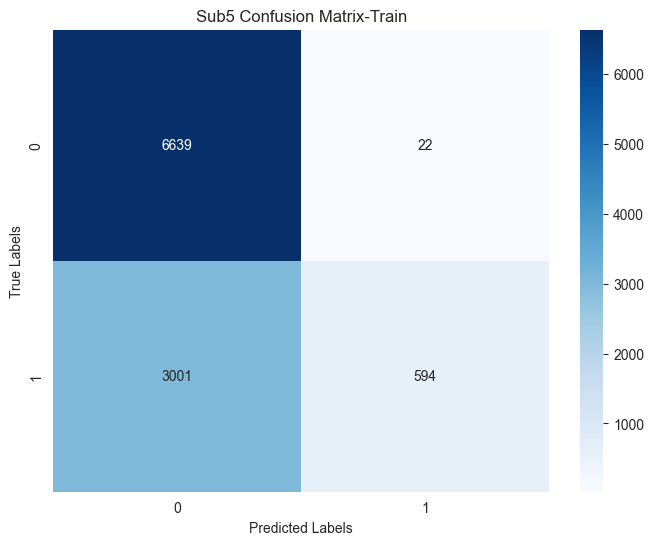

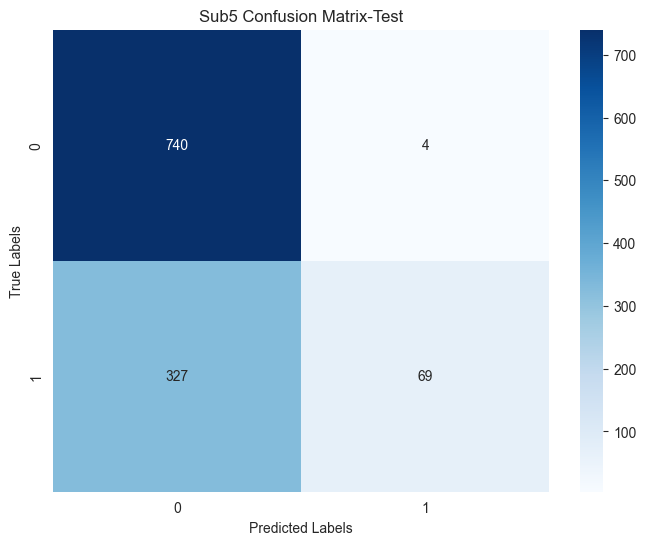

第 4 折 测试准确率: 70.96%

========== 第 5/10 折 ==========
Fold [5/10], Epoch [1/500], Step [1/41], Loss: 0.8442
Fold [5/10], Epoch [1/500], Step [11/41], Loss: 0.6608
Fold [5/10], Epoch [1/500], Step [21/41], Loss: 0.6609
Fold [5/10], Epoch [1/500], Step [31/41], Loss: 0.6453
Fold [5/10], Epoch [1/500], Step [41/41], Loss: 0.6883
Fold [5/10], Epoch [101/500], Step [1/41], Loss: 0.4411
Fold [5/10], Epoch [101/500], Step [11/41], Loss: 0.4127
Fold [5/10], Epoch [101/500], Step [21/41], Loss: 0.4393
Fold [5/10], Epoch [101/500], Step [31/41], Loss: 0.4503
Fold [5/10], Epoch [101/500], Step [41/41], Loss: 0.5851
Fold [5/10], Epoch [201/500], Step [1/41], Loss: 0.4445
Fold [5/10], Epoch [201/500], Step [11/41], Loss: 0.5119
Fold [5/10], Epoch [201/500], Step [21/41], Loss: 0.4593
Fold [5/10], Epoch [201/500], Step [31/41], Loss: 0.4535
Fold [5/10], Epoch [201/500], Step [41/41], Loss: 0.4872
Fold [5/10], Epoch [301/500], Step [1/41], Loss: 0.4492
Fold [5/10], Epoch [301/500], Step [11/41], Loss: 

<Figure size 640x480 with 0 Axes>

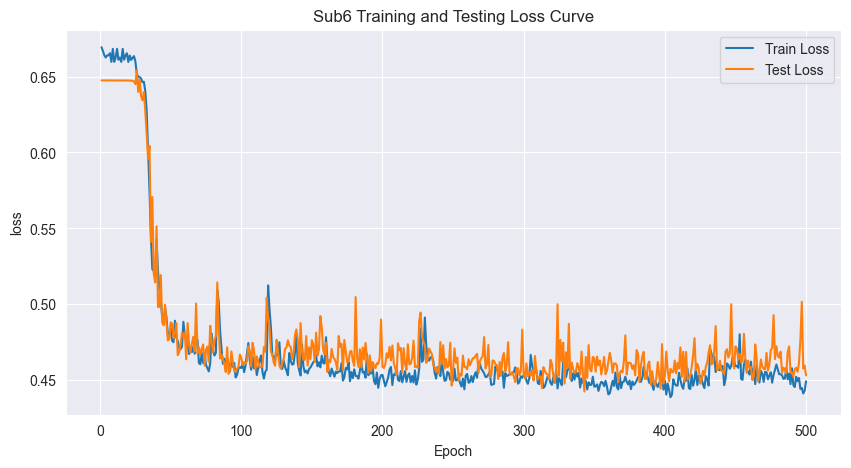

<Figure size 640x480 with 0 Axes>

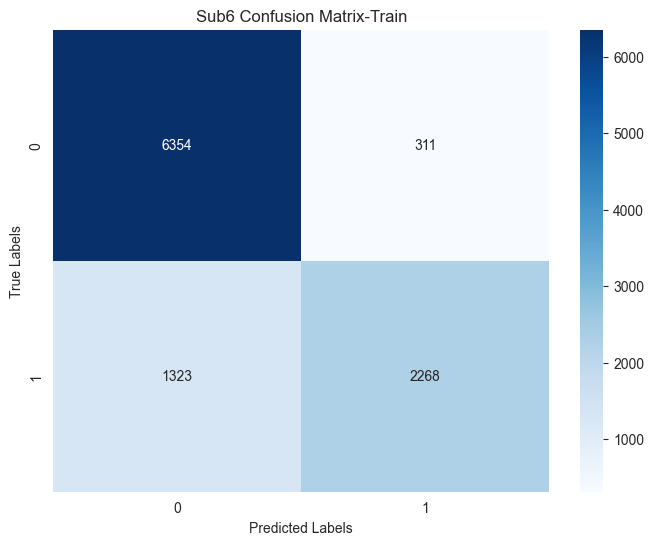

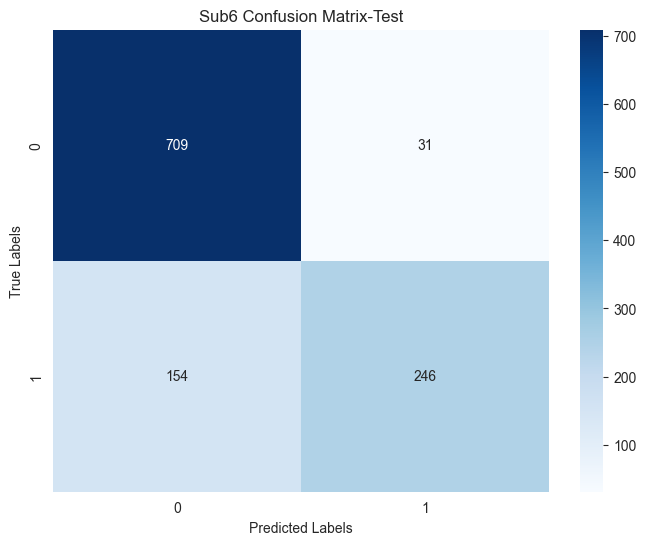

第 5 折 测试准确率: 83.77%

========== 第 6/10 折 ==========
Fold [6/10], Epoch [1/500], Step [1/41], Loss: 0.8277
Fold [6/10], Epoch [1/500], Step [11/41], Loss: 0.6217
Fold [6/10], Epoch [1/500], Step [21/41], Loss: 0.6804
Fold [6/10], Epoch [1/500], Step [31/41], Loss: 0.6258
Fold [6/10], Epoch [1/500], Step [41/41], Loss: 0.5633
Fold [6/10], Epoch [101/500], Step [1/41], Loss: 0.4541
Fold [6/10], Epoch [101/500], Step [11/41], Loss: 0.4604
Fold [6/10], Epoch [101/500], Step [21/41], Loss: 0.4355
Fold [6/10], Epoch [101/500], Step [31/41], Loss: 0.4571
Fold [6/10], Epoch [101/500], Step [41/41], Loss: 0.3916
Fold [6/10], Epoch [201/500], Step [1/41], Loss: 0.4915
Fold [6/10], Epoch [201/500], Step [11/41], Loss: 0.4495
Fold [6/10], Epoch [201/500], Step [21/41], Loss: 0.4386
Fold [6/10], Epoch [201/500], Step [31/41], Loss: 0.4529
Fold [6/10], Epoch [201/500], Step [41/41], Loss: 0.4385
Fold [6/10], Epoch [301/500], Step [1/41], Loss: 0.4349
Fold [6/10], Epoch [301/500], Step [11/41], Loss: 

<Figure size 640x480 with 0 Axes>

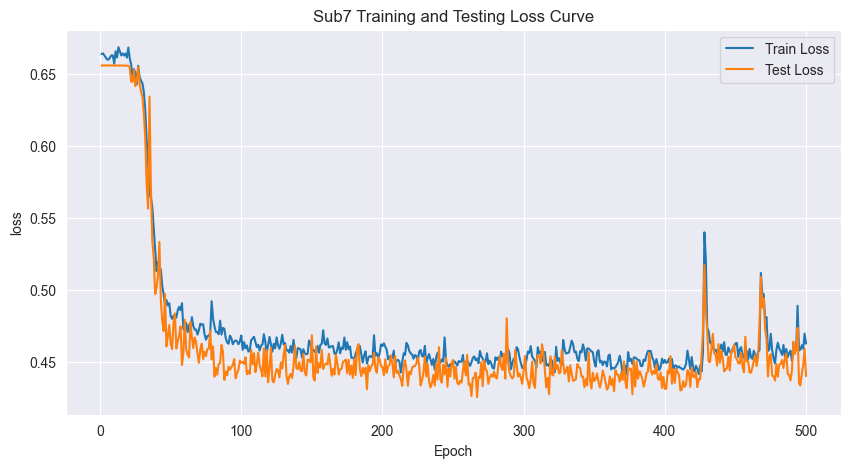

<Figure size 640x480 with 0 Axes>

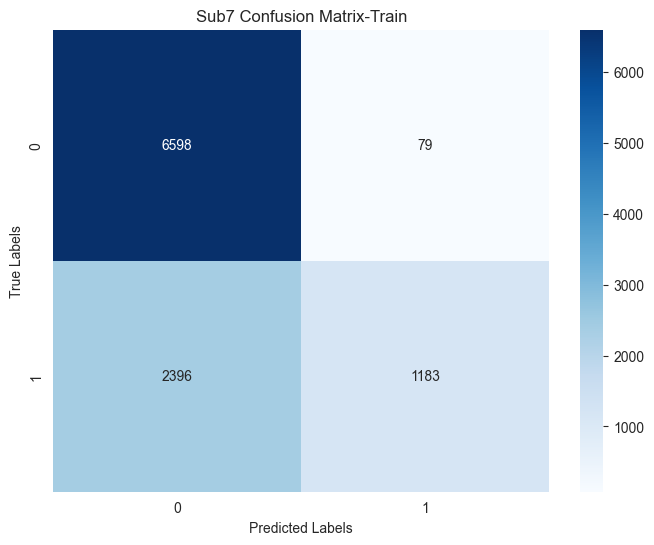

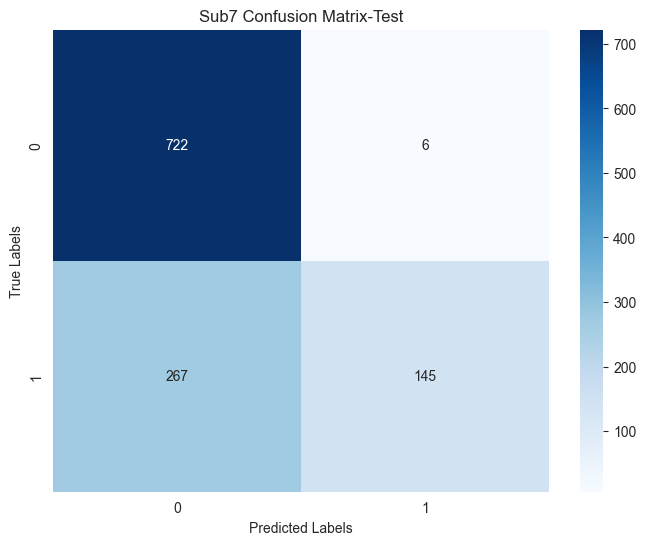

第 6 折 测试准确率: 76.05%

========== 第 7/10 折 ==========
Fold [7/10], Epoch [1/500], Step [1/41], Loss: 0.6780
Fold [7/10], Epoch [1/500], Step [11/41], Loss: 0.6551
Fold [7/10], Epoch [1/500], Step [21/41], Loss: 0.6554
Fold [7/10], Epoch [1/500], Step [31/41], Loss: 0.6635
Fold [7/10], Epoch [1/500], Step [41/41], Loss: 0.6990
Fold [7/10], Epoch [101/500], Step [1/41], Loss: 0.4456
Fold [7/10], Epoch [101/500], Step [11/41], Loss: 0.4658
Fold [7/10], Epoch [101/500], Step [21/41], Loss: 0.5098
Fold [7/10], Epoch [101/500], Step [31/41], Loss: 0.4646
Fold [7/10], Epoch [101/500], Step [41/41], Loss: 0.5003
Fold [7/10], Epoch [201/500], Step [1/41], Loss: 0.4609
Fold [7/10], Epoch [201/500], Step [11/41], Loss: 0.4808
Fold [7/10], Epoch [201/500], Step [21/41], Loss: 0.4030
Fold [7/10], Epoch [201/500], Step [31/41], Loss: 0.4304
Fold [7/10], Epoch [201/500], Step [41/41], Loss: 0.3738
Fold [7/10], Epoch [301/500], Step [1/41], Loss: 0.4283
Fold [7/10], Epoch [301/500], Step [11/41], Loss: 

<Figure size 640x480 with 0 Axes>

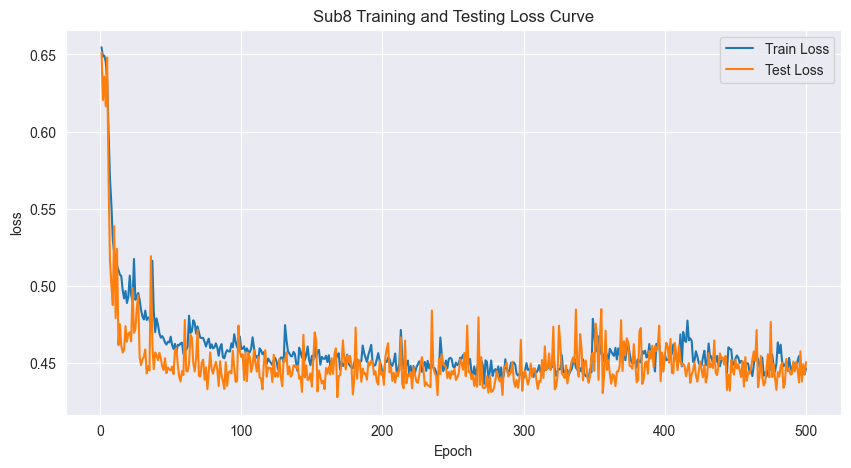

<Figure size 640x480 with 0 Axes>

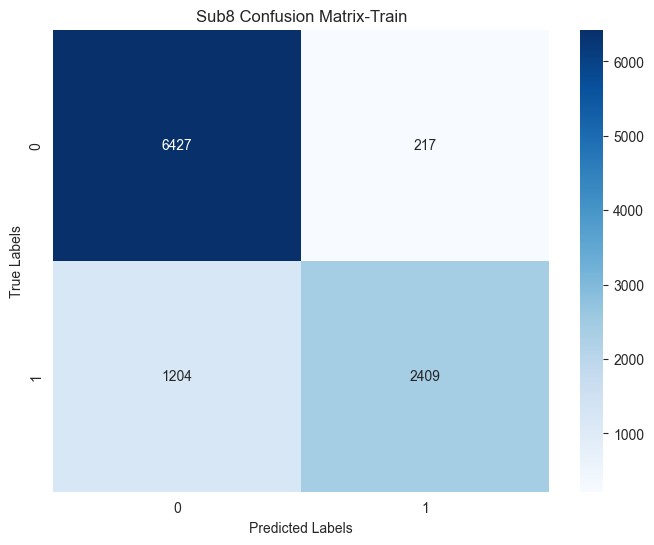

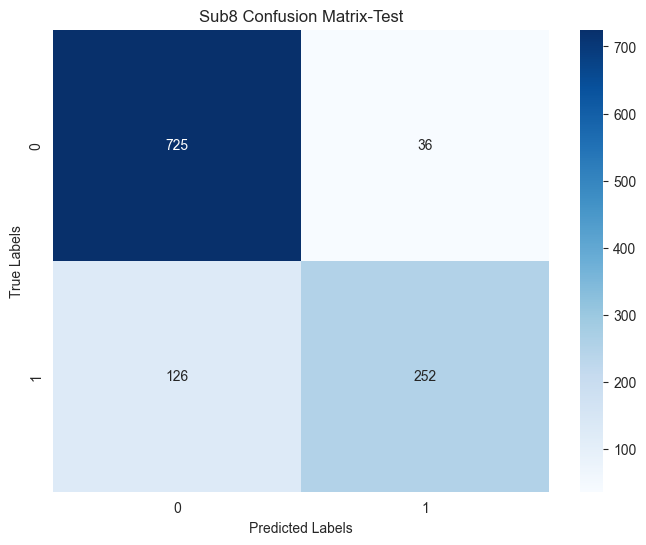

第 7 折 测试准确率: 85.78%

========== 第 8/10 折 ==========
Fold [8/10], Epoch [1/500], Step [1/41], Loss: 0.7063
Fold [8/10], Epoch [1/500], Step [11/41], Loss: 0.6486
Fold [8/10], Epoch [1/500], Step [21/41], Loss: 0.6652
Fold [8/10], Epoch [1/500], Step [31/41], Loss: 0.6763
Fold [8/10], Epoch [1/500], Step [41/41], Loss: 0.6494
Fold [8/10], Epoch [101/500], Step [1/41], Loss: 0.4101
Fold [8/10], Epoch [101/500], Step [11/41], Loss: 0.4307
Fold [8/10], Epoch [101/500], Step [21/41], Loss: 0.4914
Fold [8/10], Epoch [101/500], Step [31/41], Loss: 0.4391
Fold [8/10], Epoch [101/500], Step [41/41], Loss: 0.4897
Fold [8/10], Epoch [201/500], Step [1/41], Loss: 0.4429
Fold [8/10], Epoch [201/500], Step [11/41], Loss: 0.4590
Fold [8/10], Epoch [201/500], Step [21/41], Loss: 0.4366
Fold [8/10], Epoch [201/500], Step [31/41], Loss: 0.4458
Fold [8/10], Epoch [201/500], Step [41/41], Loss: 0.4216
Fold [8/10], Epoch [301/500], Step [1/41], Loss: 0.4454
Fold [8/10], Epoch [301/500], Step [11/41], Loss: 

<Figure size 640x480 with 0 Axes>

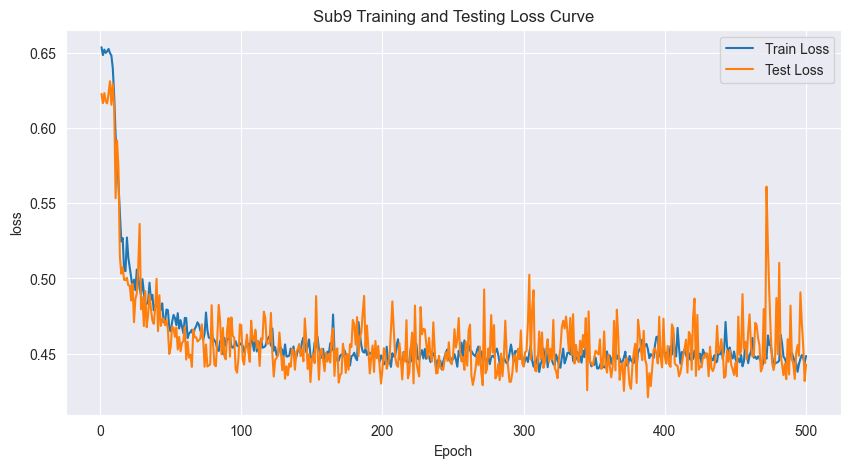

<Figure size 640x480 with 0 Axes>

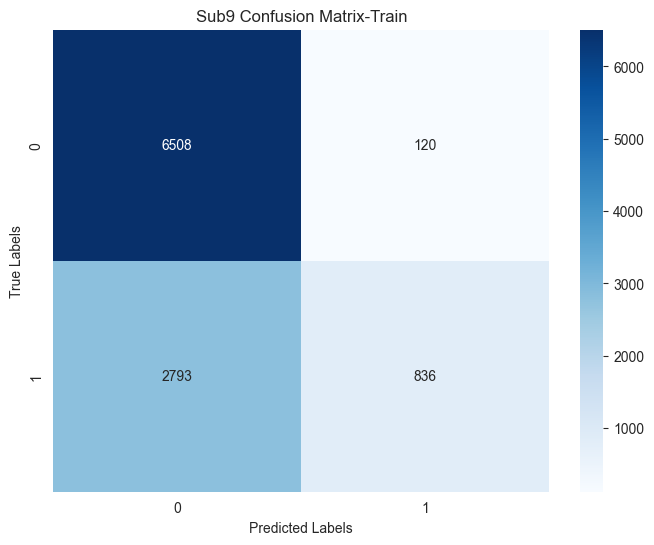

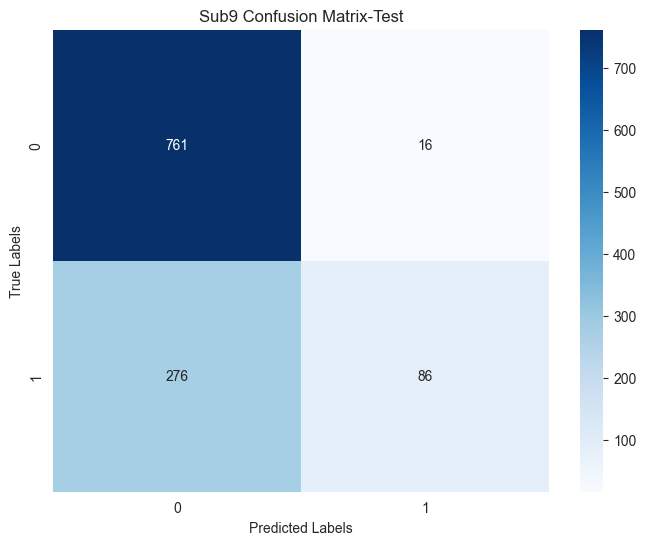

第 8 折 测试准确率: 74.36%

========== 第 9/10 折 ==========
Fold [9/10], Epoch [1/500], Step [1/41], Loss: 0.7129
Fold [9/10], Epoch [1/500], Step [11/41], Loss: 0.6475
Fold [9/10], Epoch [1/500], Step [21/41], Loss: 0.6553
Fold [9/10], Epoch [1/500], Step [31/41], Loss: 0.6504
Fold [9/10], Epoch [1/500], Step [41/41], Loss: 0.6908
Fold [9/10], Epoch [101/500], Step [1/41], Loss: 0.4584
Fold [9/10], Epoch [101/500], Step [11/41], Loss: 0.4802
Fold [9/10], Epoch [101/500], Step [21/41], Loss: 0.4439
Fold [9/10], Epoch [101/500], Step [31/41], Loss: 0.4435
Fold [9/10], Epoch [101/500], Step [41/41], Loss: 0.4467
Fold [9/10], Epoch [201/500], Step [1/41], Loss: 0.4080
Fold [9/10], Epoch [201/500], Step [11/41], Loss: 0.4189
Fold [9/10], Epoch [201/500], Step [21/41], Loss: 0.4547
Fold [9/10], Epoch [201/500], Step [31/41], Loss: 0.4327
Fold [9/10], Epoch [201/500], Step [41/41], Loss: 0.4697
Fold [9/10], Epoch [301/500], Step [1/41], Loss: 0.4624
Fold [9/10], Epoch [301/500], Step [11/41], Loss: 

<Figure size 640x480 with 0 Axes>

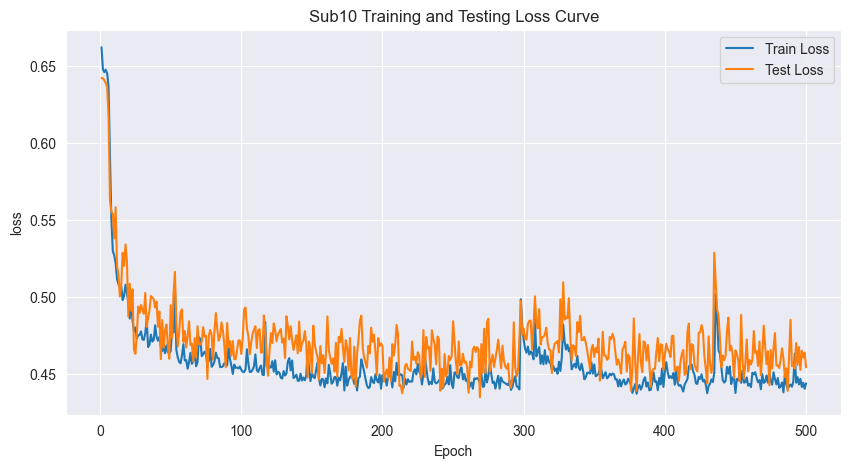

<Figure size 640x480 with 0 Axes>

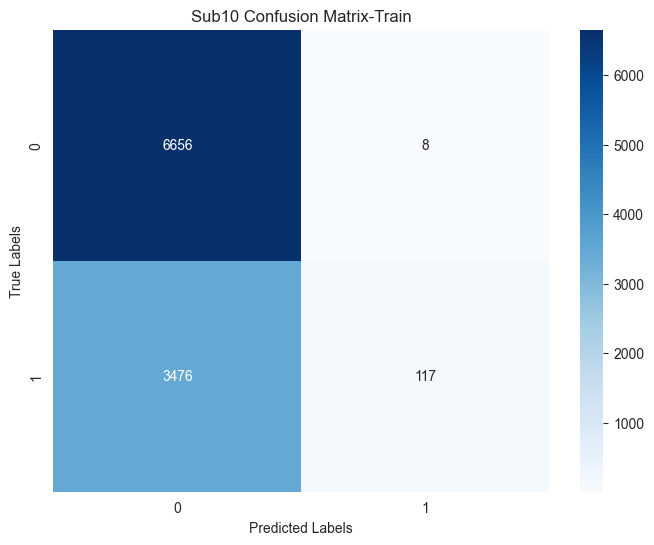

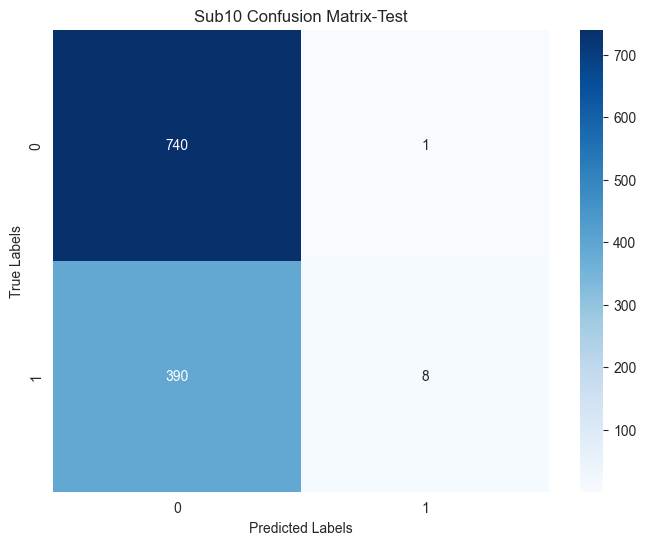

第 9 折 测试准确率: 65.67%

========== 第 10/10 折 ==========
Fold [10/10], Epoch [1/500], Step [1/41], Loss: 0.7198
Fold [10/10], Epoch [1/500], Step [11/41], Loss: 0.6798
Fold [10/10], Epoch [1/500], Step [21/41], Loss: 0.6569
Fold [10/10], Epoch [1/500], Step [31/41], Loss: 0.6413
Fold [10/10], Epoch [1/500], Step [41/41], Loss: 0.4898
Fold [10/10], Epoch [101/500], Step [1/41], Loss: 0.4540
Fold [10/10], Epoch [101/500], Step [11/41], Loss: 0.4308
Fold [10/10], Epoch [101/500], Step [21/41], Loss: 0.4349
Fold [10/10], Epoch [101/500], Step [31/41], Loss: 0.4427
Fold [10/10], Epoch [101/500], Step [41/41], Loss: 0.4086
Fold [10/10], Epoch [201/500], Step [1/41], Loss: 0.4295
Fold [10/10], Epoch [201/500], Step [11/41], Loss: 0.4666
Fold [10/10], Epoch [201/500], Step [21/41], Loss: 0.4216
Fold [10/10], Epoch [201/500], Step [31/41], Loss: 0.4489
Fold [10/10], Epoch [201/500], Step [41/41], Loss: 0.5133
Fold [10/10], Epoch [301/500], Step [1/41], Loss: 0.4555
Fold [10/10], Epoch [301/500], St

<Figure size 640x480 with 0 Axes>

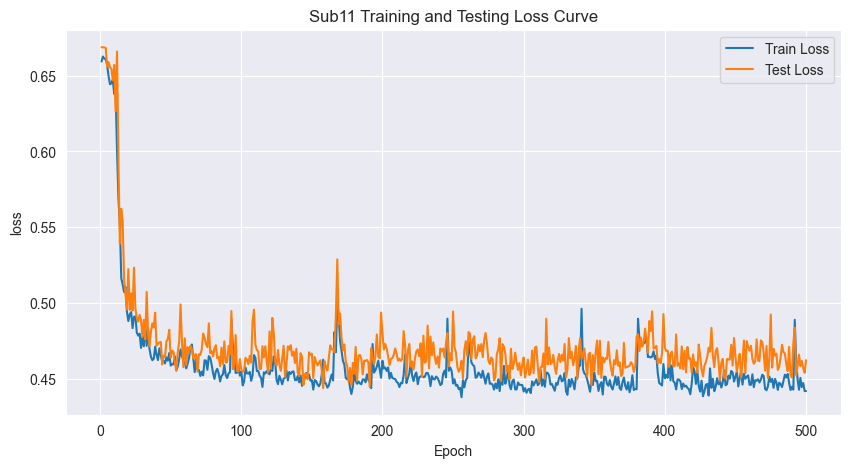

<Figure size 640x480 with 0 Axes>

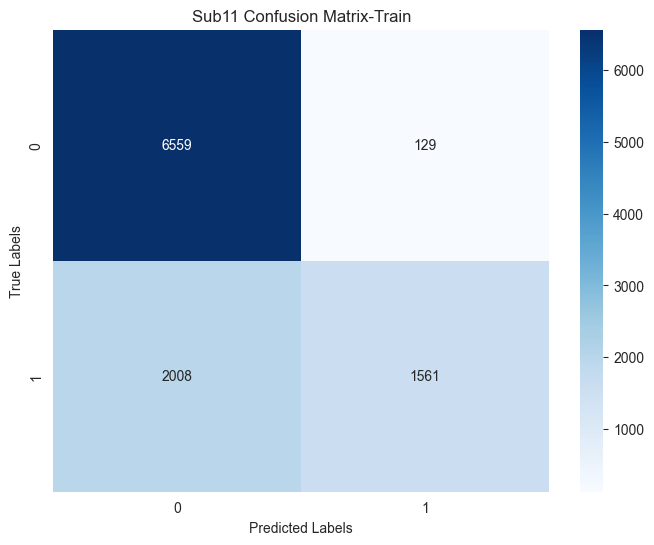

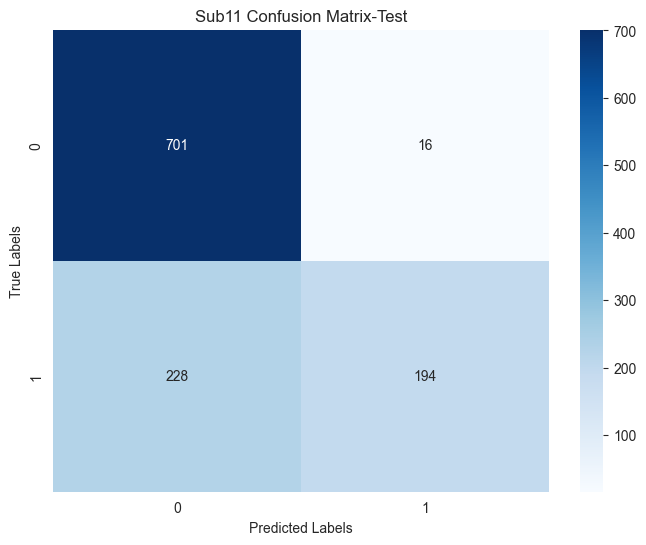

第 10 折 测试准确率: 78.58%

========== 10 折交叉验证最终结果 ==========
平均测试准确率: 77.98% (±6.78%)
各折准确率: ['88.16%', '82.89%', '73.60%', '70.96%', '83.77%', '76.05%', '85.78%', '74.36%', '65.67%', '78.58%']


<Figure size 640x480 with 0 Axes>

In [12]:
datas = []
test_datas = []

# 定义超参数（保持不变）
lr = 0.01
wd = 0.001
bs = 256
op = 'SGD'
dr = 0.5
epoches = 500
all_loocv_accuracies = []  # 新增：保存11次LOOCV的准确率
all_loocv_train_losses = []  # 新增：保存11次的训练损失
all_loocv_test_losses = []   # 新增：保存11次的测试损失

import numpy as np
from sklearn.model_selection import KFold
import torch
from torch.utils.data import TensorDataset, DataLoader

# ====================== 原始数据处理（建议加上 squeeze） ======================
predata = torch.Tensor(EEGsample)
label = torch.Tensor(substate).long().squeeze()           # 确保一维
index = torch.Tensor(subindex).long().squeeze() - 1       # 确保一维，形状 [11396]

inpt = predata.reshape(-1, 1, 17, 384)                    # (11396, 1, 17, 384)

print("=== 数据维度检查 ===")
print("inpt.shape  =", inpt.shape)
print("label.shape =", label.shape)
print("index.shape =", index.shape)

# ====================== 改为 10-Fold Cross Validation ======================
n_folds = 10
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)   # random_state 保证可复现

all_fold_accuracies = []
all_fold_train_losses = []
all_fold_test_losses = []

print(f"\n========== 开始 {n_folds} 折交叉验证 ==========")

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(inpt)):
    print(f"\n========== 第 {fold_idx+1}/{n_folds} 折 ==========")

    # 1. 根据索引拆分数据（直接用 numpy/pytorch 的 advanced indexing）
    train_inpt  = inpt[train_idx]
    train_label = label[train_idx]
    test_inpt   = inpt[test_idx]
    test_label  = label[test_idx]

    # 2. 构建 Dataset 和 DataLoader
    train_dataset = TensorDataset(train_inpt, train_label)
    test_dataset  = TensorDataset(test_inpt, test_label)

    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    test_loader  = DataLoader(test_dataset, batch_size=bs, shuffle=False)

    # 3. 每次折都重新初始化模型和优化器（非常重要）
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    net = EEGViT(drop_out=dr).to(device)

    criterion = nn.CrossEntropyLoss().to(device)
    if op == 'Adam':
        optimizer = optim.Adam(net.parameters(), lr=lr, weight_decay=wd)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epoches, eta_min=0)
    else:
        optimizer = optim.SGD(net.parameters(), lr=lr, weight_decay=wd, momentum=0.9, nesterov=True)

    # 4. 训练循环（保持你原来的逻辑）
    train_losses = []
    test_losses = []

    for epoch in range(epoches):
        net.train()
        train_loss = 0.0

        for i, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            if op == 'Adam':
                scheduler.step()

            if epoch % 100 == 0 and i % 10 == 0:
                print(f'Fold [{fold_idx+1}/{n_folds}], Epoch [{epoch+1}/{epoches}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # 测试损失（调用你原来的 get_losses 函数）
        test_losses = get_losses(test_losses, test_loader, net, device)

    # 5. 评估本折结果
    net.eval()
    all_train_targets, all_train_predictions = get_predictions(train_loader, net, device)
    all_test_targets, all_test_predictions   = get_predictions(test_loader, net, device)

    # 保存曲线和混淆矩阵（保持你原来的路径逻辑）
    sub_path = os.path.join(path, 'EEGViT', f'fold_{fold_idx+1}')
    os.makedirs(sub_path, exist_ok=True)
    loss_curve(epoches, train_losses, test_losses, folder_path=sub_path, sub=fold_idx+1)
    plt.clf()
    plot_confusion_matrix(all_train_targets, all_train_predictions,
                         all_test_targets, all_test_predictions,
                         folder_path=sub_path, sub=fold_idx+1)
    plt.clf()

    # 计算准确率
    test_accuracy = calculate_accuracy(test_loader, net, device)
    all_fold_accuracies.append(test_accuracy)
    print(f'第 {fold_idx+1} 折 测试准确率: {test_accuracy:.2f}%')

    # 保存损失
    all_fold_train_losses.append(train_losses)
    all_fold_test_losses.append(test_losses)

# ====================== 最终结果 ======================
mean_accuracy = np.mean(all_fold_accuracies)
std_accuracy  = np.std(all_fold_accuracies)

print(f"\n========== {n_folds} 折交叉验证最终结果 ==========")
print(f'平均测试准确率: {mean_accuracy:.2f}% (±{std_accuracy:.2f}%)')
print(f'各折准确率: {[f"{acc:.2f}%" for acc in all_fold_accuracies]}')

# 写入报告
with open(report_path, 'a') as f:
    f.write(f'\n{n_folds}-Fold CV 平均准确率: {mean_accuracy:.2f}% (标准差: {std_accuracy:.2f}%)\n')
    f.write(f'各折准确率: {[f"{acc:.2f}%" for acc in all_fold_accuracies]}\n')